Gauntlet #2 – Day 4 Advanced Challenge
You have to produce two deliverables:
A static 2×2 dashboard using plt.subplots(2,2).
A separate animated GIF of a projectile motion.
All data is provided below.

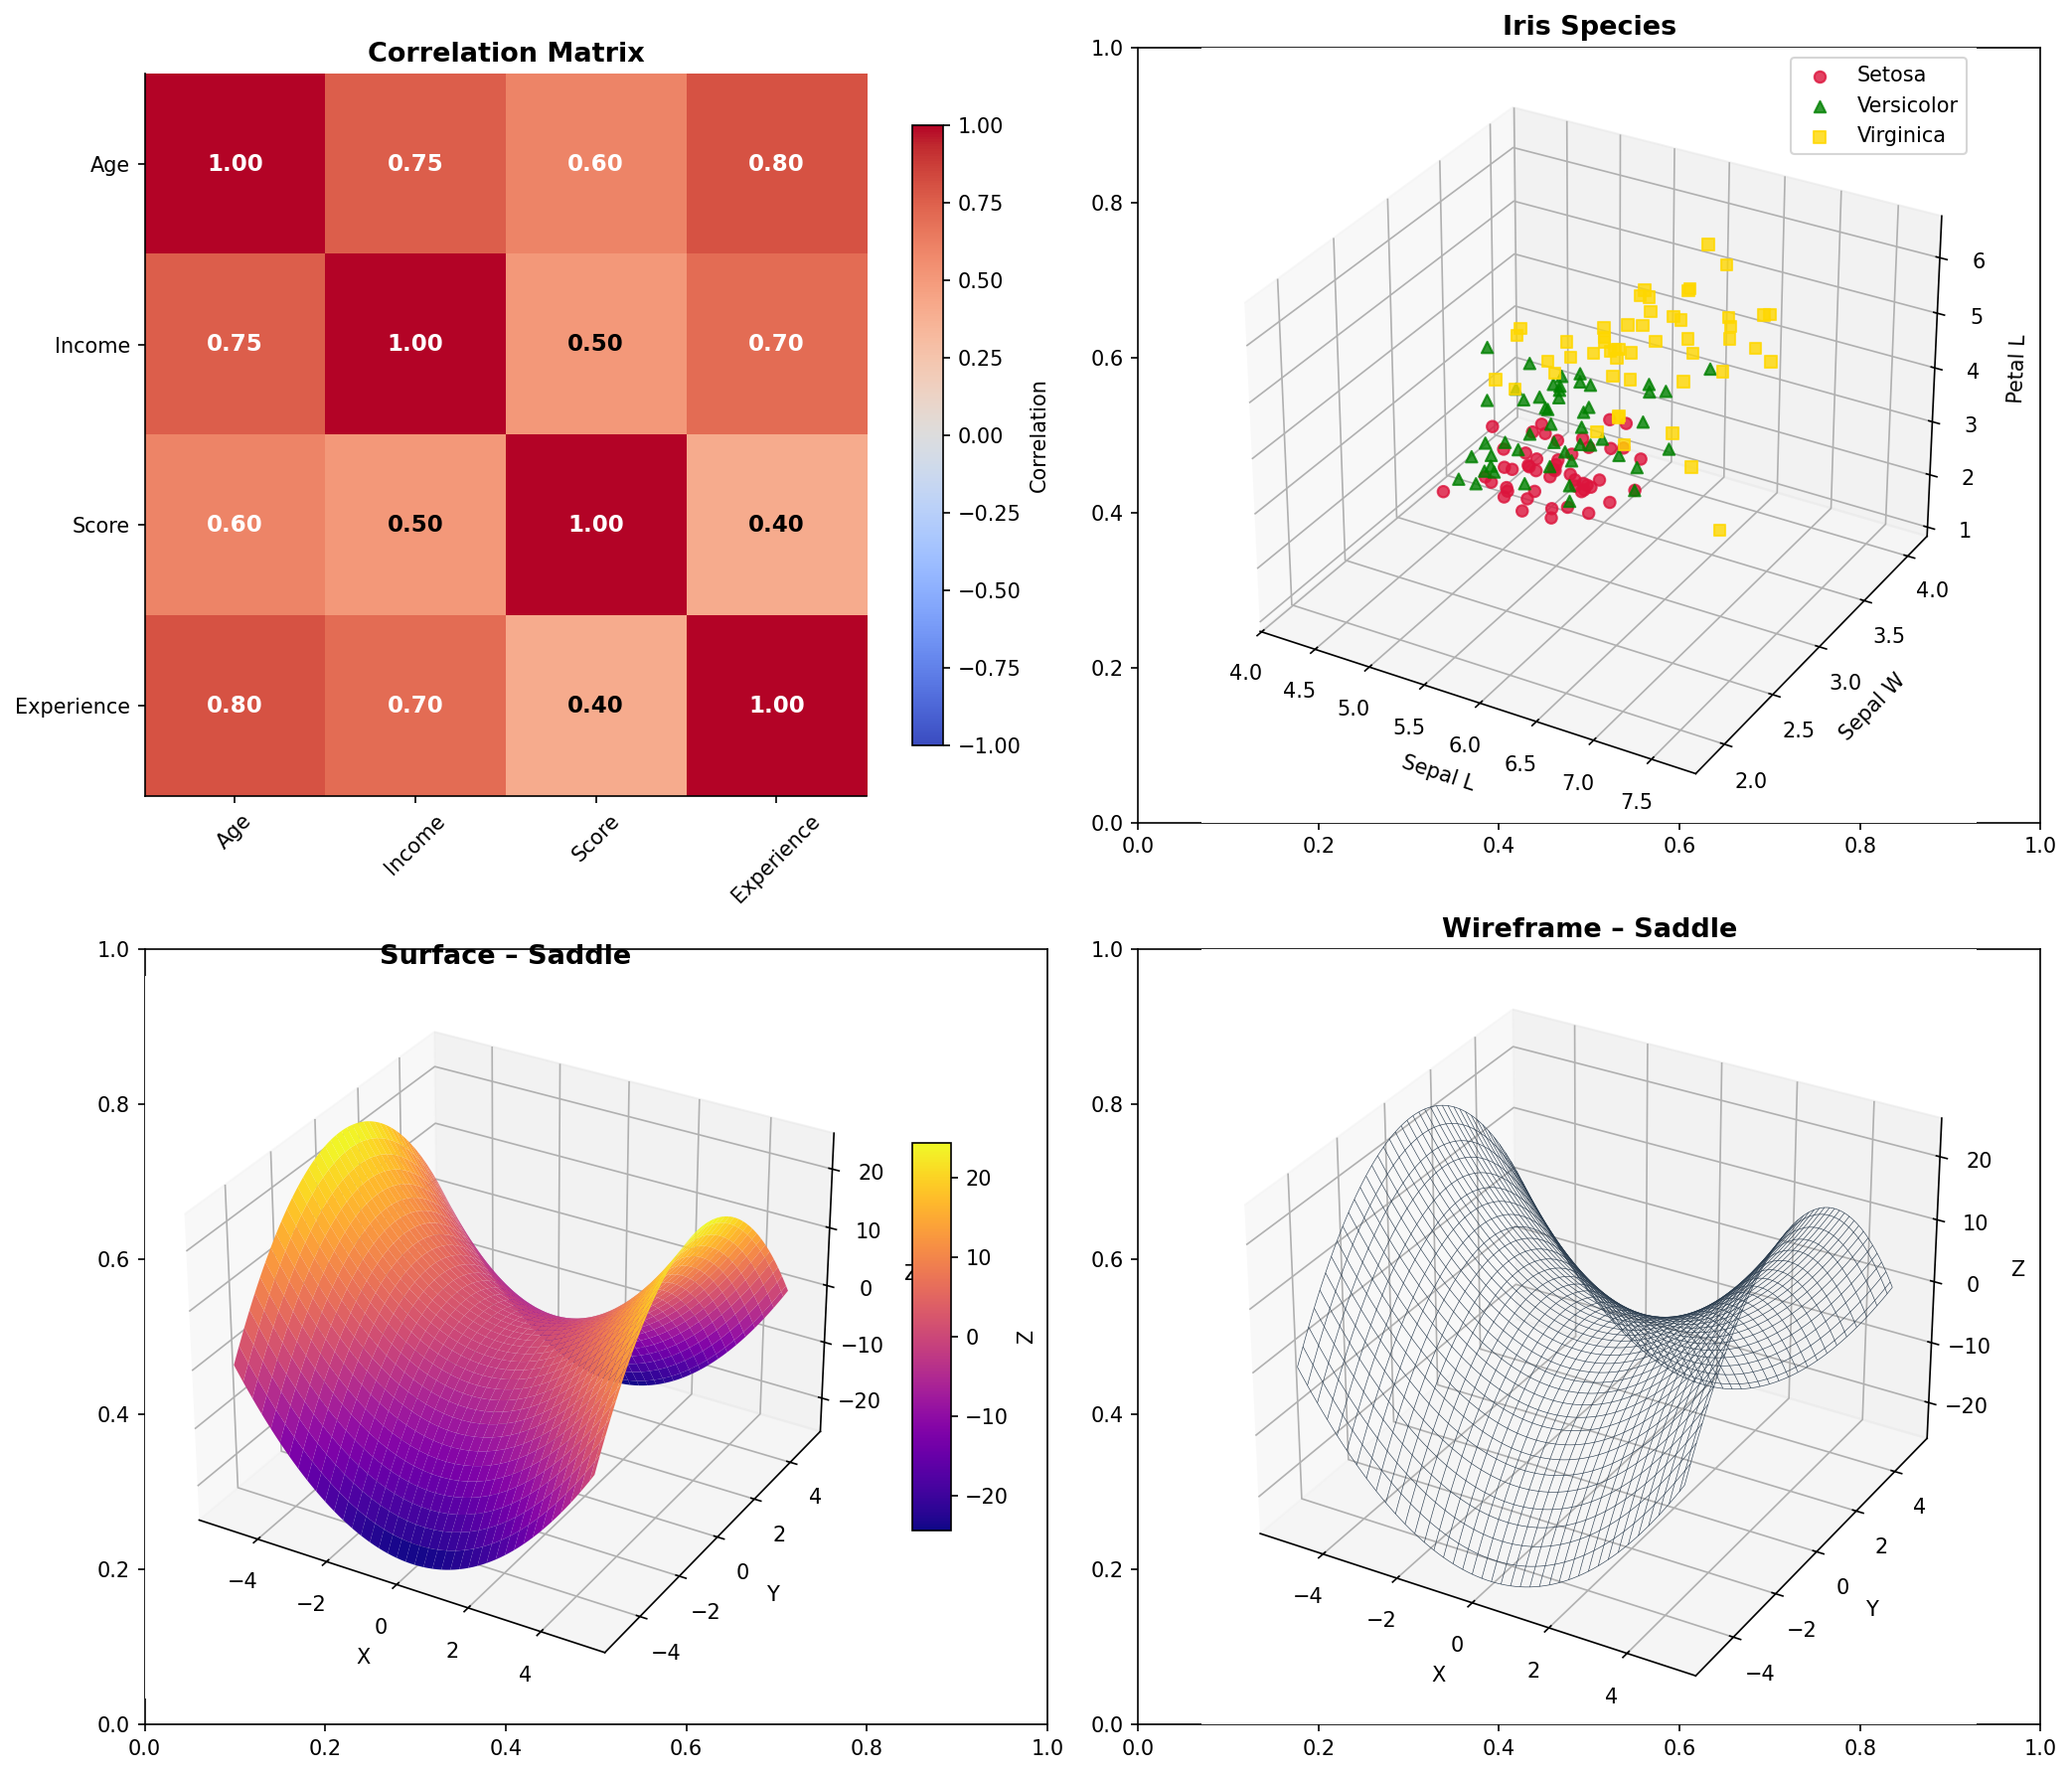

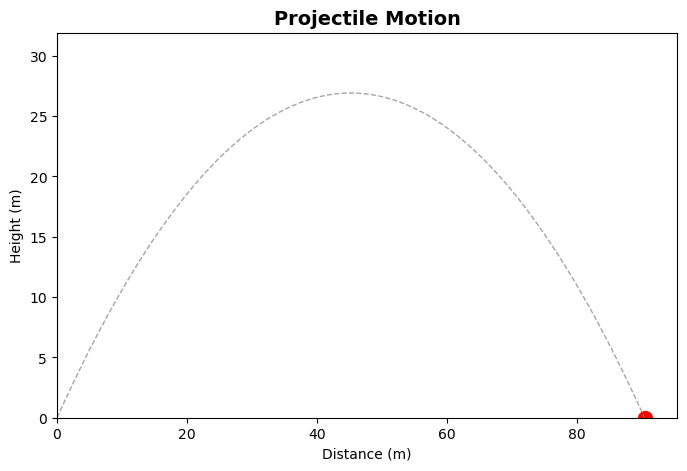

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.ticker as mticker

# ============================================================================
# PART A – Static Dashboard (2×2)
# ============================================================================

# ---------- Given data ----------
# Heatmap
corr_data = np.array([
    [1.00, 0.75, 0.60, 0.80],
    [0.75, 1.00, 0.50, 0.70],
    [0.60, 0.50, 1.00, 0.40],
    [0.80, 0.70, 0.40, 1.00]
])
features = ['Age', 'Income', 'Score', 'Experience']

# 3D Scatter
np.random.seed(0)
n = 50
setosa = np.column_stack([
    np.random.normal(5.0, 0.3, n),
    np.random.normal(3.5, 0.3, n),
    np.random.normal(1.5, 0.2, n)
])
versicolor = np.column_stack([
    np.random.normal(5.9, 0.4, n),
    np.random.normal(2.7, 0.4, n),
    np.random.normal(4.2, 0.4, n)
])
virginica = np.column_stack([
    np.random.normal(6.5, 0.5, n),
    np.random.normal(3.0, 0.5, n),
    np.random.normal(5.5, 0.5, n)
])

# Saddle function
def saddle(x, y):
    return x**2 - y**2

x_vals = np.linspace(-5, 5, 80)
y_vals = np.linspace(-5, 5, 80)
X, Y = np.meshgrid(x_vals, y_vals)
Z = saddle(X, Y)

# ---------- Create the 2×2 dashboard ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=150)

# Panel A: Heatmap (top-left)
ax_a = axes[0, 0]
heatmap = ax_a.imshow(corr_data, cmap='coolwarm', vmin=-1, vmax=1, aspect='equal')
cbar_a = plt.colorbar(heatmap, ax=ax_a, shrink=0.8)
cbar_a.set_label('Correlation')

# Label ticks
ax_a.set_xticks(range(len(features)))
ax_a.set_yticks(range(len(features)))
ax_a.set_xticklabels(features, rotation=45)
ax_a.set_yticklabels(features)

# Annotate each cell
for i in range(len(features)):
    for j in range(len(features)):
        ax_a.text(j, i, f'{corr_data[i, j]:.2f}', ha='center', va='center',
                  fontsize=11, fontweight='bold',
                  color='white' if abs(corr_data[i, j]) > 0.5 else 'black')

ax_a.set_title("Correlation Matrix", fontweight='bold', fontsize=13)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# Panel B: 3D Scatter (top-right)
ax_b = fig.add_subplot(2, 2, 2, projection='3d')   # override axes[0,1] with 3D
ax_b.scatter(setosa[:,0], setosa[:,1], setosa[:,2],
             c='crimson', marker='o', s=30, alpha=0.8, label='Setosa')
ax_b.scatter(versicolor[:,0], versicolor[:,1], versicolor[:,2],
             c='green', marker='^', s=30, alpha=0.8, label='Versicolor')
ax_b.scatter(virginica[:,0], virginica[:,1], virginica[:,2],
             c='gold', marker='s', s=30, alpha=0.8, label='Virginica')

ax_b.set_xlabel('Sepal L')
ax_b.set_ylabel('Sepal W')
ax_b.set_zlabel('Petal L')
ax_b.set_title("Iris Species", fontweight='bold', fontsize=13)
ax_b.legend()

# Panel C: 3D Surface (bottom-left)
ax_c = fig.add_subplot(2, 2, 3, projection='3d')
surf = ax_c.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none')
cbar_c = fig.colorbar(surf, ax=ax_c, shrink=0.5, aspect=10)
cbar_c.set_label('Z')
ax_c.set_xlabel('X')
ax_c.set_ylabel('Y')
ax_c.set_zlabel('Z')
ax_c.set_title("Surface – Saddle", fontweight='bold', fontsize=13)

# Panel D: 3D Wireframe (bottom-right)
ax_d = fig.add_subplot(2, 2, 4, projection='3d')
ax_d.plot_wireframe(X, Y, Z, color='#2C3E50', linewidth=0.3)
ax_d.set_xlabel('X')
ax_d.set_ylabel('Y')
ax_d.set_zlabel('Z')
ax_d.set_title("Wireframe – Saddle", fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

# ============================================================================
# PART B – Projectile Animation
# ============================================================================

# ---------- Projectile data ----------
g = 9.81
v0 = 30          # initial speed (m/s)
angle = 50       # launch angle in degrees
theta = np.radians(angle)
t_flight = 2 * v0 * np.sin(theta) / g
t = np.linspace(0, t_flight, 100)
x_proj = v0 * np.cos(theta) * t
y_proj = v0 * np.sin(theta) * t - 0.5 * g * t**2

# ---------- Figure for animation ----------
fig_anim, ax_anim = plt.subplots(figsize=(8, 5), dpi=100)
ax_anim.set_xlim(0, max(x_proj) + 5)
ax_anim.set_ylim(0, max(y_proj) + 5)
ax_anim.set_title("Projectile Motion", fontsize=14, fontweight='bold')
ax_anim.set_xlabel("Distance (m)")
ax_anim.set_ylabel("Height (m)")

# Plot the full trajectory as a dashed grey line
ax_anim.plot(x_proj, y_proj, linestyle='--', color='grey', alpha=0.7, linewidth=1)

# Empty scatter for the moving dot
proj_dot = ax_anim.scatter([], [], s=100, c='red')

def update(frame):
    proj_dot.set_offsets([[x_proj[frame], y_proj[frame]]])
    return proj_dot,

anim = FuncAnimation(fig_anim, update, frames=len(t), interval=30, repeat=True)

# Save as GIF (requires Pillow for 'pillow' writer)
anim.save('projectile.gif', writer='pillow', fps=25)

plt.show()